In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
resumes = pd.read_csv("../data/resumes_cleaned.csv")
jobs = pd.read_csv("../data/jobs_cleaned.csv")

In [5]:
resume_texts = resumes['cleaned_resume']
job_texts = jobs['cleaned_skills']

In [6]:
all_text = pd.concat([resume_texts, job_texts])

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

tfidf_matrix = tfidf.fit_transform(all_text)

In [8]:
resume_vectors = tfidf_matrix[:len(resume_texts)]
job_vectors = tfidf_matrix[len(resume_texts):]

## **Similarity and Matching**

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

In [10]:
similarity_matrix = cosine_similarity(resume_vectors, job_vectors)

In [11]:
match_scores = similarity_matrix * 100

In [12]:
best_job_index = match_scores.argmax(axis=1)
best_match_score = match_scores.max(axis=1)

In [13]:
recommended_jobs = jobs.iloc[best_job_index]['Job Title'].values

results = pd.DataFrame({
    'Resume_ID': range(len(resumes)),
    'Recommended Job': recommended_jobs,
    'Match Score (%)': best_match_score
})

In [14]:
results.head()

,Resume_ID,Recommended Job,Match Score (%)
0,0,Elasticsearch Developer,23.637372
1,1,Data Scientist,12.227736
2,2,Jupyter Developer,20.461481
3,3,Tableau Specialist,24.731700
4,4,Talend Developer,12.119143


In [15]:
resume_skill_sets = resumes['cleaned_resume'].apply(lambda x: set(x.split()))
job_skill_sets = jobs['cleaned_skills'].apply(lambda x: set(x.split()))

In [16]:
def skill_match(resume_set, job_set):
    matched = resume_set.intersection(job_set)
    missing = job_set - resume_set
    
    if len(job_set) == 0:
        match_percent = 0
    else:
        match_percent = (len(matched) / len(job_set)) * 100
        
    return match_percent, missing

In [17]:
skill_match_percent = []
missing_skills_list = []

for i, job_idx in enumerate(best_job_index):
    match, missing = skill_match(resume_skill_sets[i], job_skill_sets[job_idx])
    
    skill_match_percent.append(match)
    missing_skills_list.append(", ".join(missing))

In [18]:
results['Skill Match %'] = skill_match_percent
results['Missing Skills'] = missing_skills_list

In [20]:
def selection_decision(score):
    if score >= 20:
        return "Selected"
    else:
        return "Not Selected"

results['Decision'] = results['Match Score (%)'].apply(selection_decision)

In [21]:
results.head()

,Resume_ID,Recommended Job,Match Score (%),Skill Match %,Missing Skills,Decision
0,0,Elasticsearch Developer,23.637372,62.500000,"performance, query, dsl",Selected
1,1,Data Scientist,12.227736,50.000000,"sql, analysis, statistic, tensorflow",Not Selected
2,2,Jupyter Developer,20.461481,62.500000,"collaboration, documentation, visualization",Selected
3,3,Tableau Specialist,24.731700,87.500000,visualization,Selected
4,4,Talend Developer,12.119143,28.571429,"quality, etl, sql, integration, talend",Not Selected


## **Model Building**

In [24]:
model_data = results[['Match Score (%)','Skill Match %','Decision']].copy()

In [25]:
model_data['Decision'] = model_data['Decision'].map({
    'Selected':1,
    'Not Selected':0
})

In [26]:
X = model_data[['Match Score (%)', 'Skill Match %']]
y = model_data['Decision']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        94
           1       1.00      1.00      1.00        99

    accuracy                           1.00       193
   macro avg       1.00      1.00      1.00       193
weighted avg       1.00      1.00      1.00       193



In [32]:
import joblib

joblib.dump(model, "../model/suitability_model.pkl")

['../model/suitability_model.pkl']

## **Evaluation**


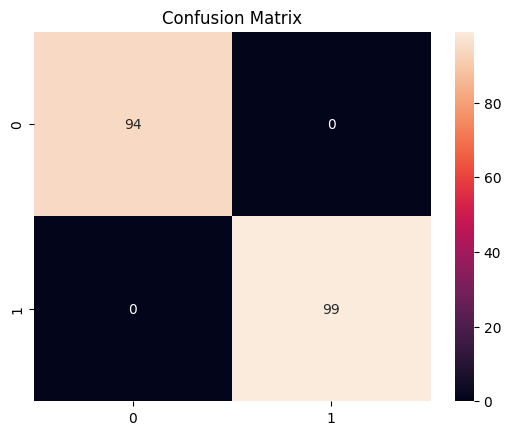

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

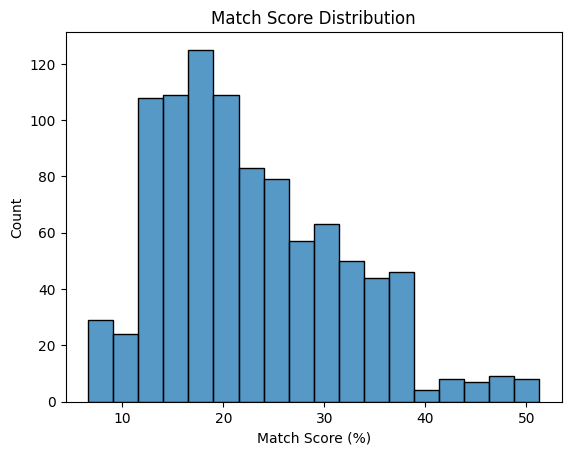

In [34]:
sns.histplot(results['Match Score (%)'])
plt.title("Match Score Distribution")
plt.show()

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [36]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 1.0


In [37]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 1.0


In [38]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 1.0
